In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import yaml
import hashlib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.xgb_train import train_xgboost
from src.models.lgbm_train import train_lightgbm
from src.models.catboost_train import train_catboost
from src.models.ensemble import create_ensemble
# CHANGED: Use sklearn metrics directly to avoid custom wrapper issues
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")


In [2]:
# ============================================================
# Corrected + Thesis-Safe Robustness Block
# - Random-label test: refit FeaturePipeline per seed
# - Cross-domain test: train+val -> test (no leakage)
# - Add Leave-One-App-Out (LOAO) by capture (merge app back)
# ============================================================

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
import sklearn.metrics as skm
import numpy as np
import pandas as pd
import xgboost as xgb

# ----------------------------
# 0) Build df_all (your part)
# ----------------------------
features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

vnat_old = pd.read_parquet(paths.data_processed / "vnat" / "features_trainable.parquet")
split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()
vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()
iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

# ----------------------------
# 1) Rebalance VNAT (capture-grouped)
# ----------------------------
logger.info("Rebalancing VNAT splits for robust evaluation...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx].copy()
vnat_temp = vnat_df.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx].copy()
vnat_test = vnat_temp.iloc[test_idx].copy()

vnat_train["split"] = "train"
vnat_val["split"] = "val"
vnat_test["split"] = "test"

vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test], ignore_index=True)
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

# Force Voipbuster split rule
vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
logger.info(f"Enforcing Voipbuster splits: {vb_train_cap} -> TRAIN, {vb_test_cap} -> TEST")
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Final splits after rebalancing:\n", df_all["split"].value_counts())

# ----------------------------
# 2) (Optional) label meaning check
# ----------------------------
print("\n" + "=" * 60)
print("LABEL CONSISTENCY CHECK")
print("=" * 60)

print("VNAT VPN label meaning check:")
print(
    vnat_flows[vnat_flows["capture_id"].astype(str).str.startswith("vpn_")]
    .groupby("capture_id")["label"].mean()
    .head(10)
)

print("\nISCX VPN label meaning check:")
print(
    iscx_flows[iscx_flows["capture_id"].astype(str).str.startswith("vpn_")]
    .groupby("capture_id")["label"].mean()
    .head(10)
)
print("=" * 60 + "\n")

# ----------------------------
# 3) Pre-flight diagnostics (safe)
# ----------------------------
logger.info("Running Pre-flight Diagnostics...")

temp_pipe = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feat_cols = temp_pipe.model_feature_names()

print(f"Detected {len(feat_cols)} features.")
print("First 30 features:", feat_cols[:30])

suspicious = [
    c for c in feat_cols
    if any(x in c.lower() for x in ["id", "label", "split", "pcap", "capture"])
]
if suspicious:
    print(f"WARNING: Suspicious feature names found: {suspicious}")

X_train_check = temp_pipe.transform(df_all[df_all["split"] == "train"])[feat_cols]
variances = X_train_check.var()
zero_var_cols = variances[variances == 0].index.tolist()
if zero_var_cols:
    print(f"WARNING: Found {len(zero_var_cols)} zero-variance features: {zero_var_cols}")

# ============================================================
# 4) Random Label Smoke Test (THESIS-SAFE)
#    - refit FeaturePipeline per seed to avoid any hidden leakage
# ============================================================
logger.info("Running Random Label Smoke Test (20 seeds, 200 trees, TEST set)...")

df_train_check = df_all[df_all["split"] == "train"].copy()
df_test_check = df_all[df_all["split"] == "test"].copy()

print("TRAIN label counts:", np.bincount(df_train_check["label"].astype(int)))
print("TEST  label counts:", np.bincount(df_test_check["label"].astype(int)))

aucs = []
for seed in range(20):
    df_noise = df_train_check.copy()
    df_noise["label"] = np.random.default_rng(seed).permutation(df_noise["label"].values)

    # refit pipeline on noise data (pipeline should be label-agnostic, but this makes it thesis-safe)
    pipe_noise = FeaturePipeline().fit(df_noise)
    feats = pipe_noise.model_feature_names()

    X_noise = pipe_noise.transform(df_noise)[feats]
    y_noise = df_noise["label"].astype(int)

    X_test = pipe_noise.transform(df_test_check)[feats]
    y_test = df_test_check["label"].astype(int)

    model_noise = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=seed,
        n_jobs=1
    )
    model_noise.fit(X_noise, y_noise)
    preds = model_noise.predict_proba(X_test)[:, 1]
    aucs.append(skm.roc_auc_score(y_test, preds))

print(f"Random Label AUCs (Test): {aucs}")
print(f"Mean Random Label AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")

# ============================================================
# 5) GroupKFold Capture Holdout (TRAIN split only) - OK
# ============================================================
logger.info("Running Robust Capture Holdout Test (GroupKFold in TRAIN only)...")

df_train_only = df_all[df_all["split"] == "train"].copy()
gkf = GroupKFold(n_splits=5)
holdout_aucs = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(df_train_only, groups=df_train_only["capture_id"])):
    df_tr = df_train_only.iloc[tr_idx].copy()
    df_te = df_train_only.iloc[te_idx].copy()

    if df_te["label"].nunique() < 2:
        print(f"Fold {fold}: Skipped (only 1 class in test)")
        continue

    pipe_ho = FeaturePipeline().fit(df_tr)
    ho_feats = pipe_ho.model_feature_names()

    X_tr = pipe_ho.transform(df_tr)[ho_feats]
    X_te = pipe_ho.transform(df_te)[ho_feats]

    model_ho = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42 + fold
    )
    model_ho.fit(X_tr, df_tr["label"].astype(int))

    p = model_ho.predict_proba(X_te)[:, 1]
    auc = skm.roc_auc_score(df_te["label"].astype(int), p)
    holdout_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

if holdout_aucs:
    print(f"GroupKFold AUC mean±std (over {len(holdout_aucs)} folds): {np.mean(holdout_aucs):.4f} +/- {np.std(holdout_aucs):.4f}")
else:
    print("WARNING: No valid holdout runs completed.")

# ============================================================
# 6) Cross-Domain Tests (THESIS-SAFE)
#    Train+Val on A -> Test on B
# ============================================================
logger.info("Running Thesis-Safe Cross-Domain Tests (train+val -> test)...")

def cross_domain_auc(train_df, test_df, tag=""):
    if train_df.empty or test_df.empty:
        print(f"{tag}: Skipped (empty train or test)")
        return None

    pipe = FeaturePipeline().fit(train_df)
    feats = pipe.model_feature_names()

    X_tr = pipe.transform(train_df)[feats]
    y_tr = train_df["label"].astype(int)

    X_te = pipe.transform(test_df)[feats]
    y_te = test_df["label"].astype(int)

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42
    )
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]

    auc = skm.roc_auc_score(y_te, p)
    auc_inv = skm.roc_auc_score(y_te, 1 - p)
    print(f"{tag} AUC: {auc:.4f} | AUC(1-p): {auc_inv:.4f}")
    return auc, auc_inv

vnat_trainval = df_all[(df_all["dataset"] == "vnat") & (df_all["split"].isin(["train", "val"]))].copy()
vnat_test     = df_all[(df_all["dataset"] == "vnat") & (df_all["split"] == "test")].copy()

iscx_trainval = df_all[(df_all["dataset"] == "iscx") & (df_all["split"].isin(["train", "val"]))].copy()
iscx_test     = df_all[(df_all["dataset"] == "iscx") & (df_all["split"] == "test")].copy()

print("\n--- Cross-Domain (Train+Val -> Test) ---")
cross_domain_auc(vnat_trainval, iscx_test, tag="VNAT(train+val) -> ISCX(test)")
cross_domain_auc(iscx_trainval, vnat_test, tag="ISCX(train+val) -> VNAT(test)")

# ============================================================
# 7) Leave-One-App-Out (LOAO) by capture (THESIS-STRONG)
#    - merge app back from flows using capture_id
#    - run LOAO on TRAIN split only (avoid leaking test)
# ============================================================
logger.info("Running Leave-One-App-Out (LOAO) Holdout (by capture, TRAIN only)...")

def cap_to_app(flows_df: pd.DataFrame) -> pd.Series:
    # choose the most common non-null app for each capture_id
    if "app" not in flows_df.columns:
        raise ValueError("flows.parquet does not contain 'app' column. Cannot run LOAO.")
    s = (
        flows_df[["capture_id", "app"]]
        .dropna(subset=["capture_id"])
        .groupby("capture_id")["app"]
        .agg(lambda x: x.dropna().value_counts().idxmax() if x.dropna().size else "unknown")
    )
    return s

cap2app = pd.concat([cap_to_app(vnat_flows), cap_to_app(iscx_flows)])
df_all["app"] = df_all["capture_id"].map(cap2app).fillna("unknown")

df_train_loao = df_all[df_all["split"] == "train"].copy()
apps = sorted([a for a in df_train_loao["app"].unique() if a != "unknown"])

loao_results = []
for app in apps:
    df_te = df_train_loao[df_train_loao["app"] == app].copy()
    df_tr = df_train_loao[df_train_loao["app"] != app].copy()

    # must have both classes in test to compute AUC
    if df_te["label"].nunique() < 2 or df_tr["label"].nunique() < 2:
        continue

    pipe = FeaturePipeline().fit(df_tr)
    feats = pipe.model_feature_names()

    X_tr = pipe.transform(df_tr)[feats]
    y_tr = df_tr["label"].astype(int)

    X_te = pipe.transform(df_te)[feats]
    y_te = df_te["label"].astype(int)

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42
    )
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]

    auc = skm.roc_auc_score(y_te, p)
    loao_results.append((app, len(df_te), auc))
    print(f"LOAO app={app:>20s} | n={len(df_te):4d} | AUC={auc:.4f}")

if loao_results:
    loao_df = pd.DataFrame(loao_results, columns=["app", "n_test", "auc"]).sort_values("auc")
    print("\nLOAO Summary (sorted by worst AUC):")
    print(loao_df.to_string(index=False))
    print(f"\nLOAO mean AUC: {loao_df['auc'].mean():.4f} +/- {loao_df['auc'].std():.4f}")
else:
    print("WARNING: LOAO produced no valid runs. Likely apps lack both classes in held-out sets.")

# ============================================================
# 8) Fit and save final pipeline (TRAIN only) - OK
# ============================================================
logger.info("Fitting and saving new FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))
logger.info(f"Pipeline saved. Model features: {len(pipeline.model_feature_names())}")

2026-03-04 04:03:15 | INFO | ai-vpn-firewall | Re-extracting VNAT features...
2026-03-04 04:03:44 | INFO | ai-vpn-firewall | Re-extracting ISCX features...
2026-03-04 04:04:33 | INFO | ai-vpn-firewall | Rebalancing VNAT splits for robust evaluation...
2026-03-04 04:04:33 | INFO | ai-vpn-firewall | Enforcing Voipbuster splits: vpn_vpn_voipbuster1a.pcap -> TRAIN, vpn_vpn_voipbuster1b.pcap -> TEST
Final splits after rebalancing:
 split
train    14260
val       3217
test      2431
Name: count, dtype: int64

LABEL CONSISTENCY CHECK
VNAT VPN label meaning check:
capture_id
vpn_netflix_capture2.pcap    1.0
vpn_rdp_capture1.pcap        1.0
vpn_rdp_capture2.pcap        1.0
vpn_rdp_capture_3.pcap       1.0
vpn_rsync_capture1.pcap      1.0
vpn_rsync_capture2.pcap      1.0
vpn_rsync_capture3.pcap      1.0
vpn_scp_capture1.pcap        1.0
vpn_scp_capture2.pcap        1.0
vpn_sftp_capture1.pcap       1.0
Name: label, dtype: float64

ISCX VPN label meaning check:
capture_id
vpn_vpn_aim_chat1a.pcap   

In [3]:
# 2. Train Individual Models
logger.info("\n" + "="*60 + "\nTraining XGBoost...")
xgb_res = train_xgboost(paths=paths, xgb_yaml=paths.configs_dir / "xgb.yaml", df=df_all)
print_metrics_summary(xgb_res.metrics)

logger.info("\n" + "="*60 + "\nTraining LightGBM...")
lgbm_res = train_lightgbm(paths=paths, lgbm_yaml=paths.configs_dir / "lgbm.yaml", df=df_all)
print_metrics_summary(lgbm_res.metrics)

logger.info("\n" + "="*60 + "\nTraining CatBoost...")
cat_res = train_catboost(paths=paths, catboost_yaml=paths.configs_dir / "catboost.yaml", df=df_all)
print_metrics_summary(cat_res.metrics)


2026-03-04 04:04:50 | INFO | ai-vpn-firewall | 
Training XGBoost...
DEBUG mean/std (first 5):
[ 0. -0. -0. -0.  0.]
[1. 1. 1. 1. 1.]
[0]	train-logloss:0.65876	train-auc:0.93478	train-aucpr:0.85135	val-logloss:0.67338	val-auc:0.88120	val-aucpr:0.74145
[100]	train-logloss:0.09509	train-auc:0.99700	train-aucpr:0.98902	val-logloss:0.24724	val-auc:0.97254	val-aucpr:0.94840
[200]	train-logloss:0.05341	train-auc:0.99933	train-aucpr:0.99697	val-logloss:0.18819	val-auc:0.98311	val-aucpr:0.96299
[300]	train-logloss:0.03382	train-auc:0.99981	train-aucpr:0.99907	val-logloss:0.15566	val-auc:0.98756	val-aucpr:0.97116
[400]	train-logloss:0.02358	train-auc:0.99992	train-aucpr:0.99962	val-logloss:0.13958	val-auc:0.98881	val-aucpr:0.97414
[500]	train-logloss:0.01721	train-auc:0.99997	train-aucpr:0.99985	val-logloss:0.13049	val-auc:0.98926	val-aucpr:0.97514
[600]	train-logloss:0.01353	train-auc:0.99999	train-aucpr:0.99993	val-logloss:0.12495	val-auc:0.98959	val-aucpr:0.97642
[700]	train-logloss:0.01070	t

In [4]:
logger.info("\n" + "="*60 + "\nCreating and Evaluating Ensemble...")
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")
print_metrics_summary(ens_res.metrics)

# NOTE: Calibration is now handled INSIDE create_ensemble, so we don't need to do it again here.
# The output parquet contains 'p_calib' directly.
df_ens_preds = pd.read_parquet(ens_res.preds_path)


2026-03-04 04:05:25 | INFO | ai-vpn-firewall | 
Creating and Evaluating Ensemble...
Ensemble Weights: {'xgb': 0.3333333333333333, 'lgbm': 0.3333333333333333, 'catboost': 0.3333333333333333}
Calibrating Ensemble...

EVALUATION SUMMARY
Global Threshold: 0.5

--- Raw Probabilities ---

Split: TRAIN
  N: 14260 (Pos: 2325, Neg: 11935)
  ROC AUC: 0.9999996756625269
  PR AUC:  0.9999983337116104
  At Threshold 0.5:
    Precision: 0.9987113402061856
    Recall:    1.0
    F1 Score:  0.9993552546744036
    Confusion Matrix: TN=11932, FP=3, FN=0, TP=2325

Split: VAL
  N: 3217 (Pos: 746, Neg: 2471)
  ROC AUC: 0.9914873117980911
  PR AUC:  0.9813603899384422
  At Threshold 0.5:
    Precision: 0.9215425531914894
    Recall:    0.9289544235924933
    F1 Score:  0.9252336448598131
    Confusion Matrix: TN=2412, FP=59, FN=53, TP=693

Split: TEST
  N: 2431 (Pos: 246, Neg: 2185)
  ROC AUC: 0.9820840542501535
  PR AUC:  0.9488207952870674
  At Threshold 0.5:
    Precision: 0.9594594594594594
    Recall: 

In [5]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

df_preds = pd.read_parquet(ens_res.preds_path)
metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

# Artifact Consistency Check
print("\n--- Artifact Consistency Check ---")
# Check if preds file has the same hash as current config
# (In a real production system, we'd store the hash in the parquet metadata or a sidecar file)
# Here we just check if the pipeline used matches the current one
current_hash = feature_config_hash_text(features_yaml)
print(f"Current Feature Config Hash: {current_hash}")
# We can't easily check the parquet file's provenance without extra metadata,
# but we can check if the feature columns match.
saved_pipe = FeaturePipeline.load(feature_art)
if saved_pipe.model_feature_names() != pipeline.model_feature_names():
    print("WARNING: Saved pipeline features do not match current pipeline features!")
else:
    print("CONFIRMED: Pipeline features match.")


T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Policy Thresholds (from VAL set on Ensemble):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]
y_hat_block = (p_calib >= T_BLOCK).astype(int)
prec_block, rec_block, _, _ = precision_recall_fscore_support(y_true, y_hat_block, average="binary", zero_division=0)
_, fp_b, _, _ = confusion_matrix(y_true, y_hat_block).ravel()
y_hat_monitor = (p_calib >= T_MONITOR).astype(int)
prec_monitor, rec_monitor, _, _ = precision_recall_fscore_support(y_true, y_hat_monitor, average="binary", zero_division=0)
_, fp_m, _, _ = confusion_matrix(y_true, y_hat_monitor).ravel()

print(f"\nBLOCK ZONE (p >= {T_BLOCK:.4f})")
print(f"  - Recall:    {rec_block:.4f}")
print(f"  - Precision: {prec_block:.4f}")
print(f"  - False Positives: {fp_b} flows")

print(f"\nMONITOR ZONE (p >= {T_MONITOR:.4f})")
print(f"  - Recall:    {rec_monitor:.4f}")
print(f"  - Precision: {prec_monitor:.4f}")
print(f"  - False Positives: {fp_m} flows")

print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
session_df = test_preds.groupby("capture_id").agg(session_score=("p_calib", "max"), session_label=("label", "max")).reset_index()
y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
_, fp_s, _, _ = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s}")

print("\n--- [3] Voipbuster Case Study ---")
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the rebalanced test set.")
print("\n" + "="*60)


ADVANCED FIREWALL EVALUATION (ENSEMBLE)

--- Artifact Consistency Check ---
Current Feature Config Hash: b34b16527d5a4daeda64ce98a591ab6c5486249b452d15839ce316600ade813e
CONFIRMED: Pipeline features match.
Policy Thresholds (from VAL set on Ensemble):
  - BLOCK:   p >= 0.9258 (Target FPR: 0.1%)
  - MONITOR: p >= 0.8580 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE (p >= 0.9258)
  - Recall:    0.5447
  - Precision: 1.0000
  - False Positives: 0 flows

MONITOR ZONE (p >= 0.8580)
  - Recall:    0.5935
  - Precision: 0.9865
  - False Positives: 2 flows

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.8125
  - Precision: 1.0000
  - False Positive Sessions: 0

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9416
  - RESULT: BLOCKED at the session level.




--- Generating Plots for Ensemble ---


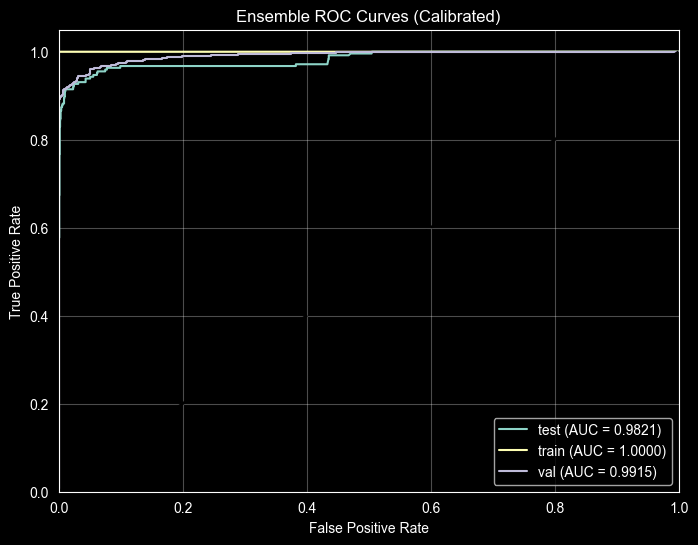

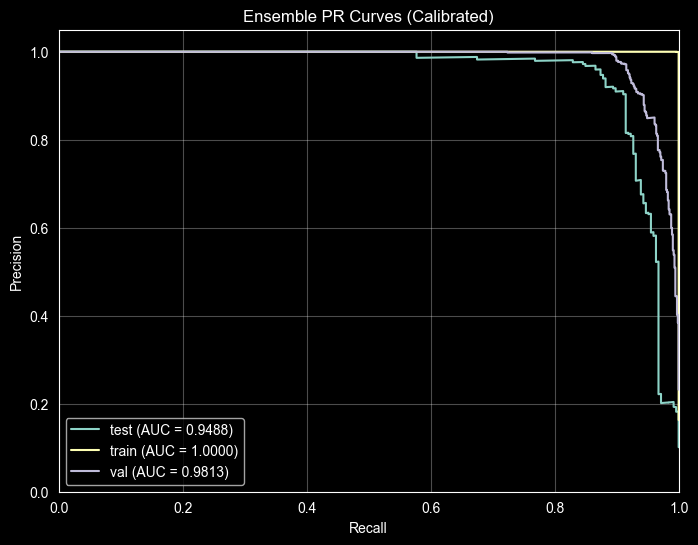

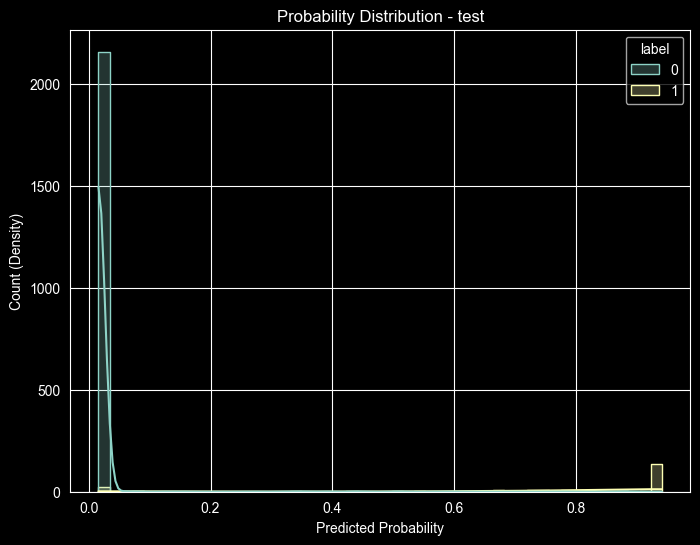

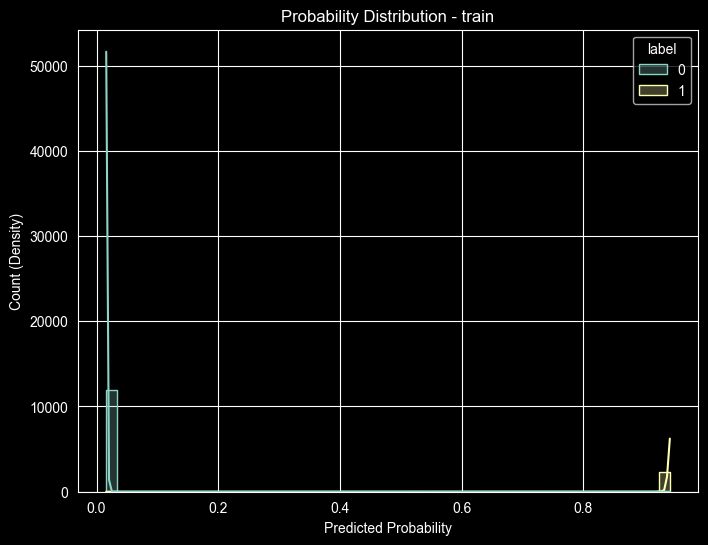

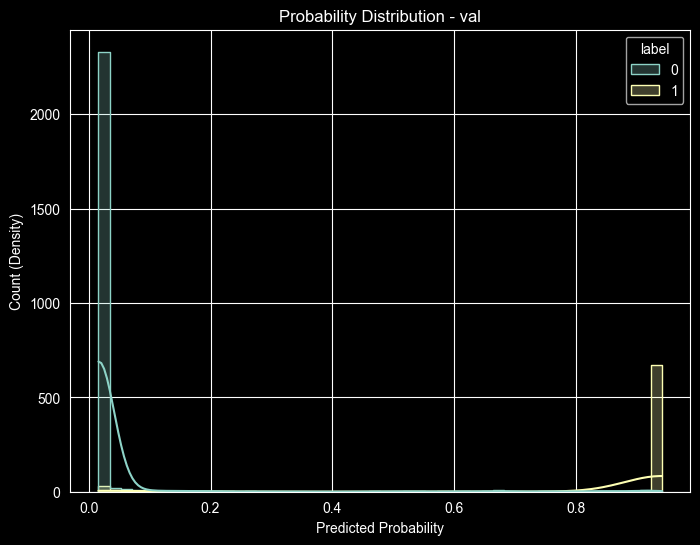

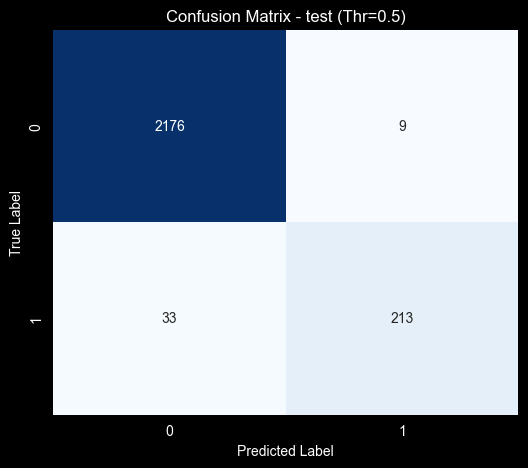

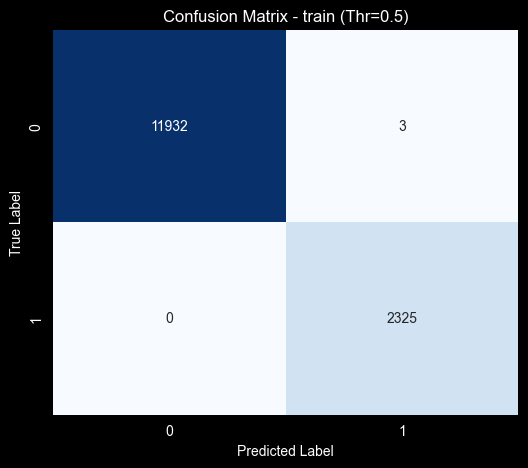

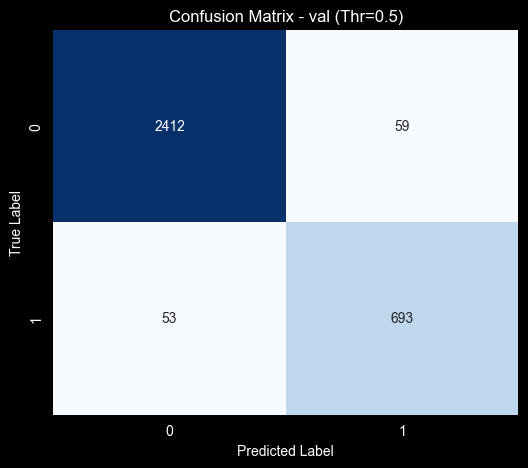

In [6]:
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)

In [7]:
# 6. Dataset Distribution Check
print("\n--- Dataset Distribution Across Splits ---")
dist_table = df_all.groupby(["dataset", "split"]).size().unstack(fill_value=0)
print(dist_table)
pct_table = dist_table.div(dist_table.sum(axis=1), axis=0) * 100
print("\n--- Percentage Distribution ---")
print(pct_table.round(2))
if (dist_table == 0).any().any(): print("\nWARNING: Some splits are empty for a dataset!")
else: print("\nCONFIRMED: Both datasets are present in all splits")



--- Dataset Distribution Across Splits ---
split    test  train   val
dataset                   
iscx     1630   8446  1725
vnat      801   5814  1492

--- Percentage Distribution ---
split     test  train    val
dataset                     
iscx     13.81  71.57  14.62
vnat      9.88  71.72  18.40

CONFIRMED: Both datasets are present in all splits
